<a href="https://colab.research.google.com/github/Kshashi22/Data_Analysis_Project/blob/main/Amazon_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# **Load Dataset**

In [2]:
file_path = "global_superstore.xlsx"

orders = pd.read_excel(file_path, sheet_name="Orders")
returns = pd.read_excel(file_path, sheet_name="Returns")
people = pd.read_excel(file_path, sheet_name="People")

In [3]:
print("Orders:", orders.shape)
print("Returns:", returns.shape)
print("People:", people.shape)

Orders: (51290, 24)
Returns: (1079, 3)
People: (24, 2)


# **Inspect the Data**

In [4]:
orders.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
orders.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,29002,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,NaN,Kure,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.10,5,0.0,4.5000,1.010,Medium
51286,34337,US-2014-ZD21925140-41765,2014-05-06,2014-05-10,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,37421.0,Chattanooga,...,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16.72,5,0.2,3.3440,1.930,High
51287,31315,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,94109.0,San Francisco,...,OFF-AR-5321,Office Supplies,Art,Newell 341,8.56,2,0.0,2.4824,1.580,High
51288,9596,MX-2013-RB1979518-41322,2013-02-17,2013-02-21,Standard Class,RB-1979518,Ross Baird,Home Office,NaN,Valinhos,...,OFF-BI-2919,Office Supplies,Binders,"Acco Index Tab, Economy",13.44,2,0.0,2.4000,1.003,Medium
51289,6147,MX-2013-MC1810093-41416,2013-05-22,2013-05-26,Second Class,MC-1810093,Mick Crebagga,Consumer,NaN,Tipitapa,...,OFF-PA-3990,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8000,1.002,High


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  object        
 10  State           51290 non-null  object        
 11  Country         51290 non-null  object        
 12  Region          51290 non-null  object        
 13  Market          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [7]:
orders.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2014-05-11 21:26:49.155780608,2014-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.478567
min,1.00000,2012-01-01 00:00:00,2012-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.002000
25%,12823.25000,2013-06-19 00:00:00,2013-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2014-07-08 00:00:00,2014-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2015-05-22 00:00:00,2015-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2015-12-31 00:00:00,2016-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.251373


In [8]:
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City',
       'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

# **Check Missing Values**

In [9]:
missing = orders.isnull().sum()

missing[missing > 0]

,0
Postal Code,41296


In [10]:
missing_percentage = (
    orders.isnull().sum() / len(orders) * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

,0
Postal Code,80.51472


# **Check Duplicate Records**

In [11]:
orders.duplicated().sum()

np.int64(0)

In [12]:
orders = orders.drop_duplicates()

# **Convert Date Columns**

In [13]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"])
orders["Ship Date"] = pd.to_datetime(orders["Ship Date"])

In [14]:
orders["Year"] = orders["Order Date"].dt.year
orders["Month"] = orders["Order Date"].dt.month
orders["Month Name"] = orders["Order Date"].dt.month_name()
orders["Quarter"] = orders["Order Date"].dt.quarter

In [15]:
orders["Shipping Days"] = (
    orders["Ship Date"] - orders["Order Date"]
).dt.days

# **Basic KPIs**

In [16]:
total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()
total_quantity = orders["Quantity"].sum()
total_orders = orders["Order ID"].nunique()
total_customers = orders["Customer ID"].nunique()
total_products = orders["Product ID"].nunique()

profit_margin = total_profit / total_sales * 100
average_order_value = total_sales / total_orders
average_shipping_days = orders["Shipping Days"].mean()
average_discount = orders["Discount"].mean() * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value:", round(average_order_value, 2))
print("Average Shipping Days:", round(average_shipping_days, 2))
print("Average Discount:", round(average_discount, 2), "%")

Total Sales: 12642501.91
Total Profit: 1467457.29
Total Quantity: 178312
Total Orders: 25728
Total Customers: 17415
Total Products: 3788
Profit Margin: 11.61 %
Average Order Value: 491.39
Average Shipping Days: 3.97
Average Discount: 14.29 %


# **Sales & Profit by Year**

In [17]:
yearly = orders.groupby("Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

yearly

,Year,Sales,Profit,Quantity
0,2012,2.259451e+06,248940.81154,31443
1,2013,2.677439e+06,307415.27910,38111
2,2014,3.405746e+06,406935.23018,48136
3,2015,4.299866e+06,504165.97046,60622


# **Visualization**

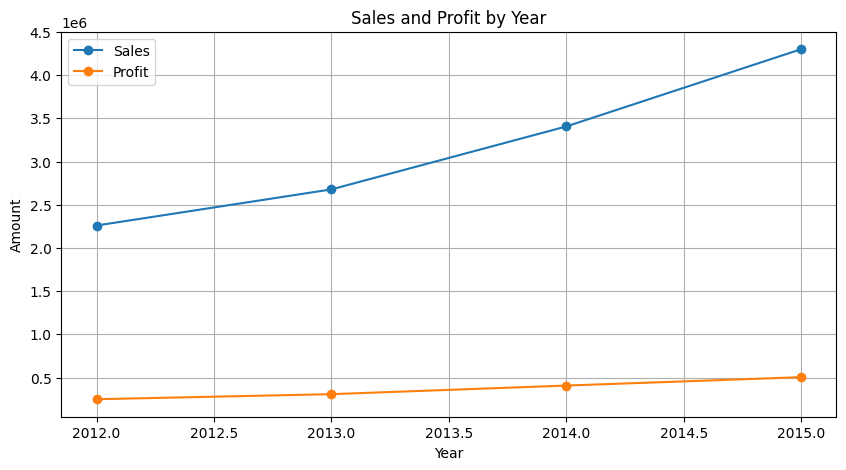

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(yearly["Year"], yearly["Sales"], marker="o", label="Sales")
plt.plot(yearly["Year"], yearly["Profit"], marker="o", label="Profit")

plt.title("Sales and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)

plt.show()

# **Year-over-Year Growth**

In [19]:
yearly["Sales Growth %"] = yearly["Sales"].pct_change() * 100
yearly["Profit Growth %"] = yearly["Profit"].pct_change() * 100

yearly

,Year,Sales,Profit,Quantity,Sales Growth %,Profit Growth %
0,2012,2.259451e+06,248940.81154,31443,NaN,NaN
1,2013,2.677439e+06,307415.27910,38111,18.499530,23.489305
2,2014,3.405746e+06,406935.23018,48136,27.201659,32.373131
3,2015,4.299866e+06,504165.97046,60622,26.253259,23.893419


# **Monthly Sales Trend**

In [20]:
monthly = (
    orders.groupby(["Year", "Month"])
    .agg(Sales=("Sales", "sum"),
         Profit=("Profit", "sum"))
    .reset_index()
)

monthly["Date"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" +
    monthly["Month"].astype(str) + "-01"
)

monthly = monthly.sort_values("Date")

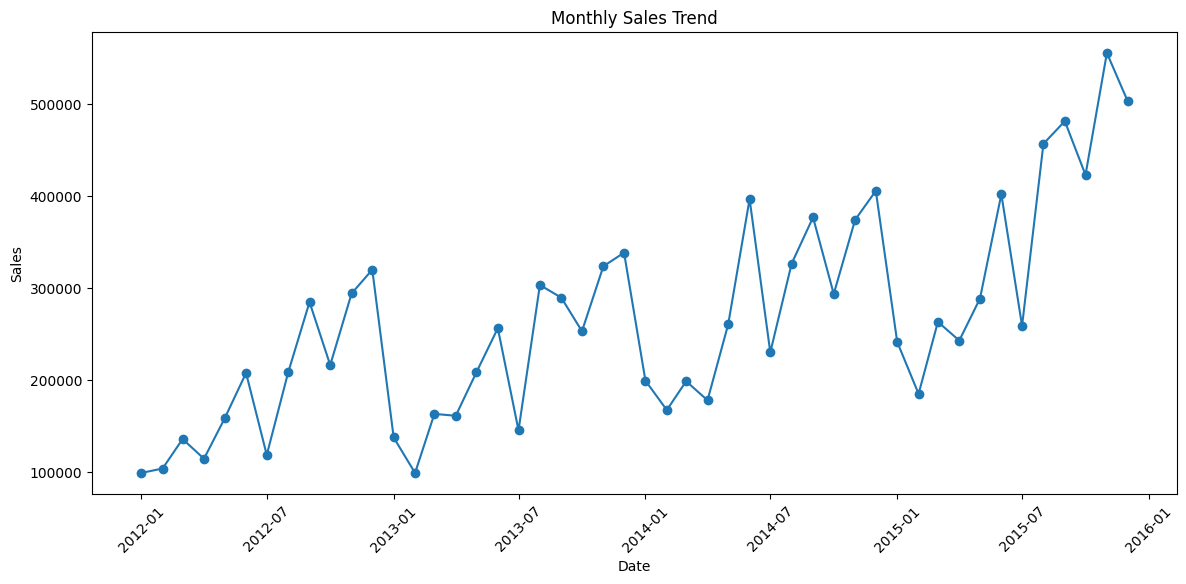

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["Date"],
    monthly["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

# **Sales by Market**

In [22]:
market = orders.groupby("Market").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

market["Profit Margin %"] = (
    market["Profit"] / market["Sales"] * 100
)

market.sort_values("Sales", ascending=False)

,Market,Sales,Profit,Quantity,Profit Margin %
1,Asia Pacific,4.042658e+06,403176.03800,48597,9.973043
2,Europe,3.287336e+06,449551.72350,41919,13.675258
4,USCA,2.364129e+06,304214.41170,38706,12.867928
3,LATAM,2.164605e+06,221643.48708,38526,10.239442
0,Africa,7.837732e+05,88871.63100,10564,11.338947


# **Profit by Market**

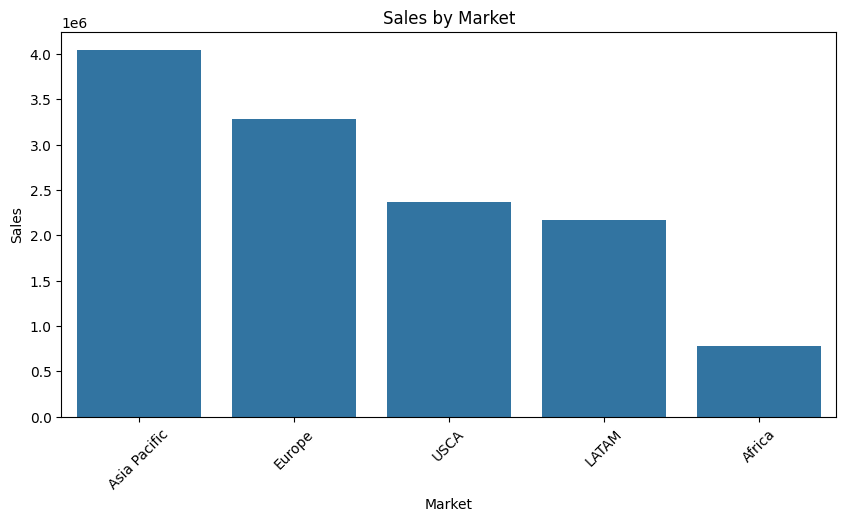

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=market.sort_values("Sales", ascending=False),
    x="Market",
    y="Sales"
)

plt.title("Sales by Market")
plt.xticks(rotation=45)

plt.show()

# **Region Analysis**

In [25]:
region = orders.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order ID", "nunique")
).reset_index()

region["Profit Margin %"] = (
    region["Profit"] / region["Sales"] * 100
)

region.sort_values("Profit", ascending=False)

,Region,Sales,Profit,Quantity,Orders,Profit Margin %
21,Western Europe,1.731930e+06,218433.50850,22262,2993,12.612147
7,Eastern Asia,8.550594e+05,167101.85100,8922,1162,19.542719
16,Southern Asia,8.665727e+05,159336.42700,9109,1346,18.386966
3,Central America,1.223101e+06,158981.64816,20882,2831,12.998248
12,Oceania,1.100185e+06,120089.11200,12838,1743,10.915360
22,Western US,7.254578e+05,108418.44890,12266,1611,14.944831
9,Eastern US,6.787812e+05,91522.78000,10618,1401,13.483399
11,Northern Europe,6.367792e+05,83923.91700,8177,1137,13.179438
8,Eastern Europe,3.100334e+05,77084.88000,3609,785,24.863408
17,Southern Europe,6.085940e+05,70109.41800,7871,1098,11.519900


In [26]:
region.sort_values(
    "Profit",
    ascending=False
).head(10)

,Region,Sales,Profit,Quantity,Orders,Profit Margin %
21,Western Europe,1.731930e+06,218433.50850,22262,2993,12.612147
7,Eastern Asia,8.550594e+05,167101.85100,8922,1162,19.542719
16,Southern Asia,8.665727e+05,159336.42700,9109,1346,18.386966
3,Central America,1.223101e+06,158981.64816,20882,2831,12.998248
12,Oceania,1.100185e+06,120089.11200,12838,1743,10.915360
22,Western US,7.254578e+05,108418.44890,12266,1611,14.944831
9,Eastern US,6.787812e+05,91522.78000,10618,1401,13.483399
11,Northern Europe,6.367792e+05,83923.91700,8177,1137,13.179438
8,Eastern Europe,3.100334e+05,77084.88000,3609,785,24.863408
17,Southern Europe,6.085940e+05,70109.41800,7871,1098,11.519900


In [27]:
region[region["Profit"] < 0].sort_values("Profit")

,Region,Sales,Profit,Quantity,Orders,Profit Margin %
20,Western Asia,317106.960,-53921.670,5441,1200,-17.004253
19,Western Africa,173878.812,-50407.788,3305,711,-28.990184
4,Central Asia,19311.459,-7282.011,465,112,-37.708238


# **Category Analysis**

In [28]:
category = orders.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

category["Profit Margin %"] = (
    category["Profit"] / category["Sales"] * 100
)

category

,Category,Sales,Profit,Quantity,Profit Margin %
0,Furniture,4.110452e+06,285082.73020,34892,6.935557
1,Office Supplies,3.787493e+06,518595.82790,108244,13.692326
2,Technology,4.744557e+06,663778.73318,35176,13.990319


# **Profit by Category**

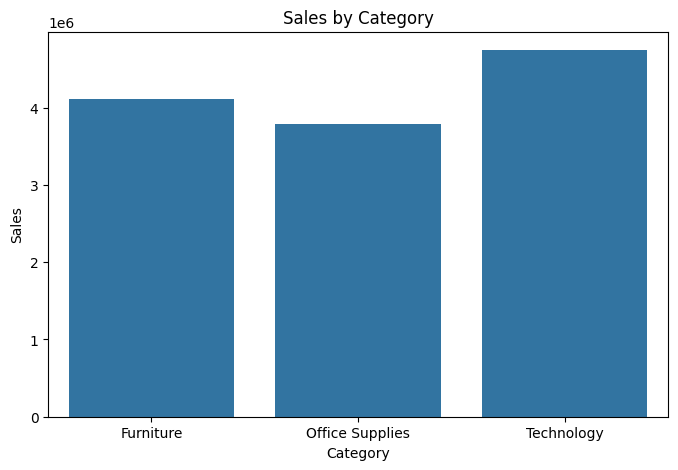

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category,
    x="Category",
    y="Sales"
)

plt.title("Sales by Category")

plt.show()

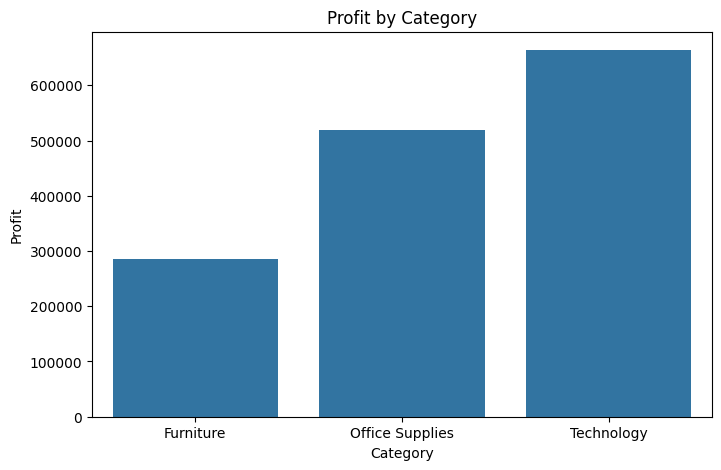

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category,
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")

plt.show()

# **Sub-Category Analysis**

In [31]:
subcategory = orders.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

subcategory["Profit Margin %"] = (
    subcategory["Profit"] /
    subcategory["Sales"] * 100
)

subcategory.sort_values("Sales", ascending=False)

,Sub-Category,Sales,Profit,Quantity,Profit Margin %
13,Phones,1.706824e+06,216717.00580,11870,12.697091
6,Copiers,1.509436e+06,258567.54818,7454,17.130074
5,Chairs,1.501682e+06,140396.26750,12336,9.349269
4,Bookcases,1.466572e+06,161924.41950,8310,11.041012
14,Storage,1.126813e+06,108416.68060,16884,9.621533
1,Appliances,1.010536e+06,141562.58770,6026,14.008670
11,Machines,7.790601e+05,58867.87300,4906,7.556269
16,Tables,7.570419e+05,-64083.38870,3083,-8.464972
0,Accessories,7.492370e+05,129626.30620,10946,17.301108
3,Binders,4.618694e+05,72433.15160,21403,15.682605


# **Top 10:**

In [32]:
subcategory.sort_values(
    "Sales",
    ascending=False
).head(10)

,Sub-Category,Sales,Profit,Quantity,Profit Margin %
13,Phones,1.706824e+06,216717.00580,11870,12.697091
6,Copiers,1.509436e+06,258567.54818,7454,17.130074
5,Chairs,1.501682e+06,140396.26750,12336,9.349269
4,Bookcases,1.466572e+06,161924.41950,8310,11.041012
14,Storage,1.126813e+06,108416.68060,16884,9.621533
1,Appliances,1.010536e+06,141562.58770,6026,14.008670
11,Machines,7.790601e+05,58867.87300,4906,7.556269
16,Tables,7.570419e+05,-64083.38870,3083,-8.464972
0,Accessories,7.492370e+05,129626.30620,10946,17.301108
3,Binders,4.618694e+05,72433.15160,21403,15.682605


# **Bottom 10 by profit:**

In [33]:
subcategory.sort_values(
    "Profit"
).head(10)

,Sub-Category,Sales,Profit,Quantity,Profit Margin %
16,Tables,757041.9244,-64083.3887,3083,-8.464972
8,Fasteners,89495.0459,13844.2889,9051,15.469335
10,Labels,73350.2760,14988.9237,9301,20.434720
15,Supplies,242811.1326,22559.1953,8482,9.290841
7,Envelopes,169217.4896,28849.4873,8210,17.048762
9,Furnishings,385155.9679,46845.4319,11163,12.162717
2,Art,371613.1539,57829.8593,16215,15.561844
12,Paper,241787.5274,58111.6535,12672,24.034182
11,Machines,779060.0671,58867.8730,4906,7.556269
3,Binders,461869.3937,72433.1516,21403,15.682605


# **Sales by Category**

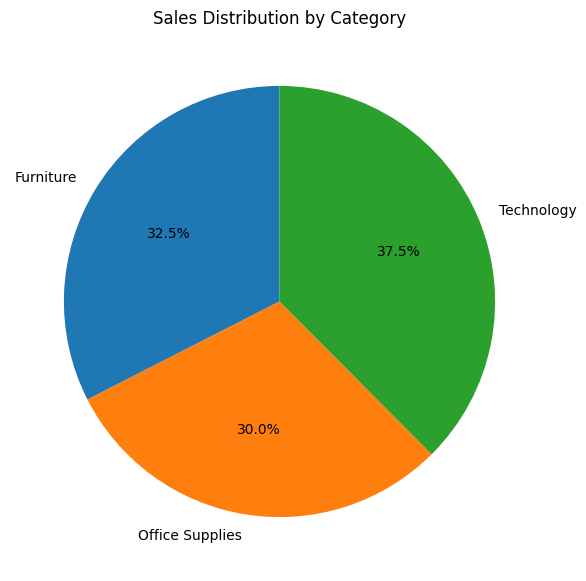

In [67]:
category_sales = orders.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Distribution by Category")
plt.show()

### **Find Loss-Making Sub-Categories**

In [34]:
loss_making = subcategory[
    subcategory["Profit"] < 0
].sort_values("Profit")

loss_making

,Sub-Category,Sales,Profit,Quantity,Profit Margin %
16,Tables,757041.9244,-64083.3887,3083,-8.464972


# **Discount Analysis**

In [36]:
orders["Discount Group"] = pd.cut(
    orders["Discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 1],
    labels=[
        "0%",
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40%+"
    ]
)

In [37]:
discount_analysis = orders.groupby(
    "Discount Group",
    observed=True
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

discount_analysis["Profit Margin %"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

discount_analysis

,Discount Group,Sales,Profit,Quantity,Profit Margin %
0,0%,6.992411e+06,1.770695e+06,98768,25.323101
1,0-10%,1.962619e+06,3.381893e+05,17607,17.231530
2,10-20%,1.757261e+06,1.732548e+05,23394,9.859367
3,20-30%,3.825547e+05,-2.115561e+04,3679,-5.530089
4,30-40%,7.013431e+05,-1.661154e+05,12415,-23.685332
5,40%+,8.463130e+05,-6.274110e+05,22449,-74.134634


# **Discount vs Profit**

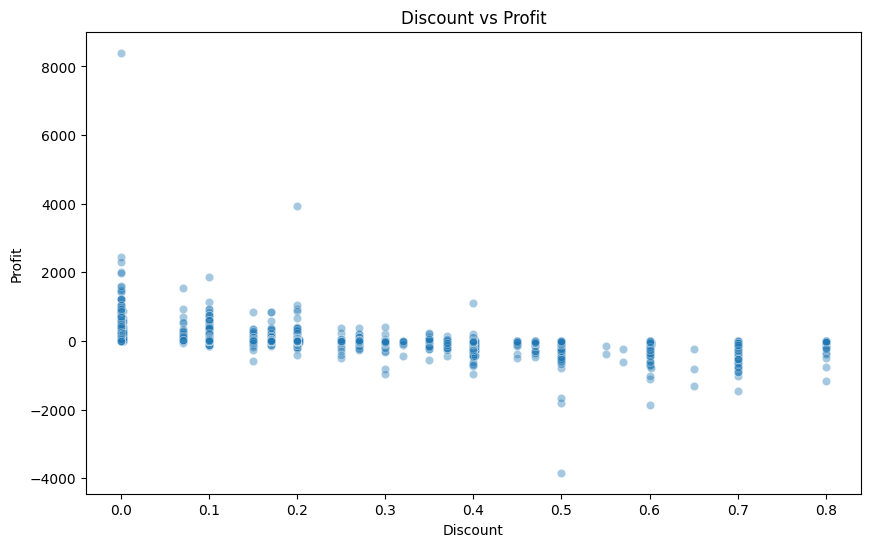

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=orders.sample(10000),
    x="Discount",
    y="Profit",
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [39]:
orders[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.00000,-0.31649
Profit,-0.31649,1.00000


# **Segment Analysis**

In [40]:
segment = orders.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).reset_index()

segment["Profit Margin %"] = (
    segment["Profit"] /
    segment["Sales"] * 100
)

segment

,Segment,Sales,Profit,Orders,Profit Margin %
0,Consumer,6.507949e+06,749239.78206,13291,11.512686
1,Corporate,3.824698e+06,441208.32866,7724,11.535771
2,Home Office,2.309855e+06,277009.18056,4713,11.992492


# **Sales by Segment**

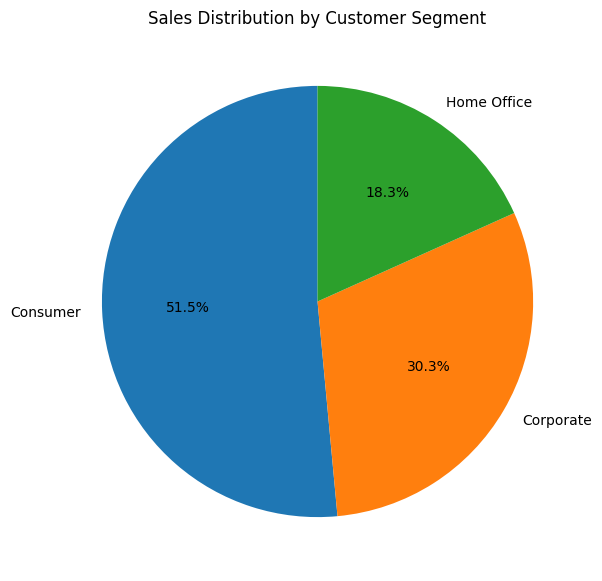

In [68]:
segment_sales = orders.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Distribution by Customer Segment")
plt.show()

# **Customer Analysis**

In [41]:
customer = orders.groupby(
    ["Customer ID", "Customer Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique"),
    Quantity=("Quantity", "sum"),
    Average_Discount=("Discount", "mean")
).reset_index()

customer["Profit Margin %"] = (
    customer["Profit"] /
    customer["Sales"] * 100
)

# **Top customers by sales**

In [42]:
customer.sort_values(
    "Sales",
    ascending=False
).head(10)

,Customer ID,Customer Name,Sales,Profit,Orders,Quantity,Average_Discount,Profit Margin %
15376,SM-203201408,Sean Miller,23669.196,-1787.0435,2,27,0.275000,-7.550081
16285,TC-209801402,Tamara Chand,18437.138,8745.0635,2,24,0.142857,47.431784
13636,RB-193601404,Raymond Buch,14345.276,6807.0879,2,23,0.033333,47.451774
16019,TA-213851406,Tom Ashbrook,13723.498,4599.2073,2,22,0.040000,33.513375
136,AB-101051402,Adrian Barton,12181.594,5362.6135,5,48,0.254545,44.022264
5035,DP-131057,Dave Poirier,11864.139,2220.3690,5,64,0.093333,18.714961
6238,FH-1436582,Fred Hopkins,10880.180,945.6000,4,61,0.092308,8.691033
1979,BM-111401402,Becky Martin,10539.896,-1878.7892,1,37,0.328571,-17.825500
7162,HL-150401406,Hunter Lopez,10522.550,5045.8564,2,5,0.000000,47.952791
2705,CA-1277558,Cynthia Arntzen,10463.010,3981.7200,3,36,0.000000,38.055206


# **Top customers by Profit**



In [43]:
customer.sort_values(
    "Profit",
    ascending=False
).head(10)

,Customer ID,Customer Name,Sales,Profit,Orders,Quantity,Average_Discount,Profit Margin %
16285,TC-209801402,Tamara Chand,18437.138,8745.0635,2,24,0.142857,47.431784
13636,RB-193601404,Raymond Buch,14345.276,6807.0879,2,23,0.033333,47.451774
136,AB-101051402,Adrian Barton,12181.594,5362.6135,5,48,0.254545,44.022264
7162,HL-150401406,Hunter Lopez,10522.550,5045.8564,2,5,0.000000,47.952791
14743,SC-200951402,Sanjit Chand,9900.190,4668.6935,1,17,0.000000,47.157615
16019,TA-213851406,Tom Ashbrook,13723.498,4599.2073,2,22,0.040000,33.513375
13081,PJ-1883564,Patrick Jones,8428.344,3982.0440,2,24,0.100000,47.245865
2705,CA-1277558,Cynthia Arntzen,10463.010,3981.7200,3,36,0.000000,38.055206
2572,BW-106533,Barry Weirich,8721.780,3261.9300,2,43,0.000000,37.399820
3469,CM-123851408,Christopher Martinez,6682.260,3197.4580,2,15,0.000000,47.849949


# **High-Sales but Low-Profit Customers**

In [44]:
customer[
    (customer["Sales"] > customer["Sales"].quantile(0.75)) &
    (customer["Profit"] < customer["Profit"].median())
].sort_values("Sales", ascending=False).head(20)

,Customer ID,Customer Name,Sales,Profit,Orders,Quantity,Average_Discount,Profit Margin %
15376,SM-203201408,Sean Miller,23669.1960,-1787.0435,2,27,0.275000,-7.550081
1979,BM-111401402,Becky Martin,10539.8960,-1878.7892,1,37,0.328571,-17.825500
6774,GT-146351408,Grant Thornton,8167.4200,-3825.3394,1,6,0.350000,-46.836570
1704,BE-114557,Brad Eason,6898.4190,-454.2810,3,51,0.290909,-6.585291
11406,ML-17395120,Marina Lichtenstein,6573.7320,-372.5880,2,28,0.040000,-5.667831
337,AD-1018059,Alan Dominguez,6120.2043,-368.1357,1,23,0.270000,-6.015088
14626,SB-202901402,Sean Braxton,5579.9400,-761.9928,1,10,0.400000,-13.655932
8966,JS-1603059,Joy Smith,5489.8311,-740.0889,3,29,0.355714,-13.481087
12944,PF-191207,Peter Fuller,5268.2940,-160.5660,2,28,0.212500,-3.047780
4128,DB-1297045,Darren Budd,5199.6090,-13.0110,3,22,0.166667,-0.250230


# **Product Analysis**

In [45]:
product = orders.groupby(
    ["Product ID", "Product Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order ID", "nunique"),
    Average_Discount=("Discount", "mean")
).reset_index()

product["Profit Margin %"] = (
    product["Profit"] /
    product["Sales"] * 100
)

# **Top products**

In [46]:
product.sort_values(
    "Sales",
    ascending=False
).head(10)

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin %
3511,TEC-PH-3148,"Apple Smart Phone, Full Size",86935.7786,5921.5786,171,51,0.106667,6.811440
3562,TEC-PH-3806,"Cisco Smart Phone, Full Size",76441.5306,17238.5206,139,38,0.054474,22.551250
3653,TEC-PH-5268,"Motorola Smart Phone, Full Size",73156.3030,17027.1130,134,38,0.147632,23.274977
3680,TEC-PH-5355,"Nokia Smart Phone, Full Size",71904.5555,9938.1955,147,47,0.144468,13.821371
3212,TEC-CO-3691,Canon imageCLASS 2200 Advanced Copier,61599.8240,25199.9280,20,5,0.120000,40.909091
251,FUR-CH-4654,"Hon Executive Leather Armchair, Adjustable",58193.4841,5997.2541,169,49,0.165510,10.305714
322,FUR-CH-5441,"Office Star Executive Leather Armchair, Adjust...",50661.6840,4710.9840,141,45,0.143778,9.298909
215,FUR-CH-4530,"Harbour Creations Executive Leather Armchair, ...",50121.5160,10427.3260,142,39,0.178974,20.804091
3761,TEC-PH-5839,"Samsung Smart Phone, Cordless",48653.4600,-198.0900,108,25,0.125385,-0.407145
3681,TEC-PH-5356,"Nokia Smart Phone, with Caller ID",47877.7857,9465.3257,96,24,0.147500,19.769765


# **Most Profitable Products**

In [47]:
product.sort_values(
    "Profit",
    ascending=False
).head(10)

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin %
3212,TEC-CO-3691,Canon imageCLASS 2200 Advanced Copier,61599.8240,25199.9280,20,5,0.120000,40.909091
3562,TEC-PH-3806,"Cisco Smart Phone, Full Size",76441.5306,17238.5206,139,38,0.054474,22.551250
3653,TEC-PH-5268,"Motorola Smart Phone, Full Size",73156.3030,17027.1130,134,38,0.147632,23.274977
1008,OFF-AP-4743,"Hoover Stove, Red",31663.7790,11807.9690,62,15,0.066667,37.291724
144,FUR-BO-5951,"Sauder Classic Bookcase, Traditional",39108.3030,10672.0730,113,29,0.118966,27.288510
215,FUR-CH-4530,"Harbour Creations Executive Leather Armchair, ...",50121.5160,10427.3260,142,39,0.178974,20.804091
3680,TEC-PH-5355,"Nokia Smart Phone, Full Size",71904.5555,9938.1955,147,47,0.144468,13.821371
3563,TEC-PH-3807,"Cisco Smart Phone, with Caller ID",43127.5008,9786.6408,85,27,0.147037,22.692344
3681,TEC-PH-5356,"Nokia Smart Phone, with Caller ID",47877.7857,9465.3257,96,24,0.147500,19.769765
2939,TEC-AC-3405,"Belkin Router, USB",23470.4080,8955.0180,110,32,0.096875,38.154505


# **Loss-Making Products**

In [48]:
loss_products = product[
    product["Profit"] < 0
].sort_values("Profit")

loss_products.head(20)

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin %
3319,TEC-MA-3854,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8879.9704,9,3,0.533333,-80.000000
3385,TEC-MA-5082,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4589.9730,18,4,0.400000,-27.272727
3652,TEC-PH-5267,"Motorola Smart Phone, Cordless",38931.0420,-4447.0380,74,23,0.118261,-11.422859
3320,TEC-MA-3855,Cubify CubeX 3D Printer Triple Head Print,7999.9800,-3839.9904,4,1,0.500000,-48.000000
719,FUR-TA-3429,"Bevis Round Table, Adjustable Height",5654.7960,-3649.8940,22,5,0.460000,-64.545105
708,FUR-TA-3418,"Bevis Computer Table, Fully Assembled",11177.8962,-3509.5638,43,13,0.353077,-31.397355
2660,OFF-ST-5700,"Rogers Lockers, Blue",28214.5892,-2893.4908,167,42,0.143571,-10.255300
744,FUR-TA-3753,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400,-2876.1156,27,5,0.280000,-29.000000
731,FUR-TA-3442,"Bevis Wood Table, with Bottom Storage",11134.6620,-2782.5880,34,10,0.320000,-24.990323
829,FUR-TA-5069,"Lesro Training Table, Rectangular",2711.6466,-2581.2834,25,5,0.582000,-95.192471


# **High Sales + Low Profit Products**

In [49]:
high_sales_low_profit = product[
    (product["Sales"] >= product["Sales"].quantile(0.75)) &
    (product["Profit"] < product["Profit"].median())
]

high_sales_low_profit.sort_values(
    "Sales",
    ascending=False
).head(20)

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin %
3761,TEC-PH-5839,"Samsung Smart Phone, Cordless",48653.46000,-1.980900e+02,108,25,0.125385,-4.071447e-01
3652,TEC-PH-5267,"Motorola Smart Phone, Cordless",38931.04200,-4.447038e+03,74,23,0.118261,-1.142286e+01
1010,OFF-AP-4745,"Hoover Stove, White",32842.60430,-2.180626e+03,81,18,0.134444,-6.639625e+00
2660,OFF-ST-5700,"Rogers Lockers, Blue",28214.58920,-2.893491e+03,167,42,0.143571,-1.025530e+01
353,FUR-CH-5775,"SAFCO Executive Leather Armchair, Red",25640.12700,-1.833173e+03,76,20,0.161905,-7.149625e+00
2693,OFF-ST-6033,"Smead File Cart, Single Width",25397.17080,-2.376692e+02,250,77,0.169610,-9.358097e-01
351,FUR-CH-5773,"SAFCO Executive Leather Armchair, Adjustable",24210.43840,-8.621816e+02,72,26,0.163077,-3.561198e+00
3318,TEC-MA-3819,Cisco TelePresence System EX90 Videoconferenci...,22638.48000,-1.811078e+03,6,1,0.500000,-8.000000e+00
86,FUR-BO-4862,"Ikea Library with Doors, Pine",22536.06880,-2.779512e+02,94,28,0.263214,-1.233362e+00
236,FUR-CH-4623,HON 5400 Series Task Chairs for Big and Tall,21870.57600,4.547474e-13,39,8,0.200000,2.079266e-15


# **Sales by Market**

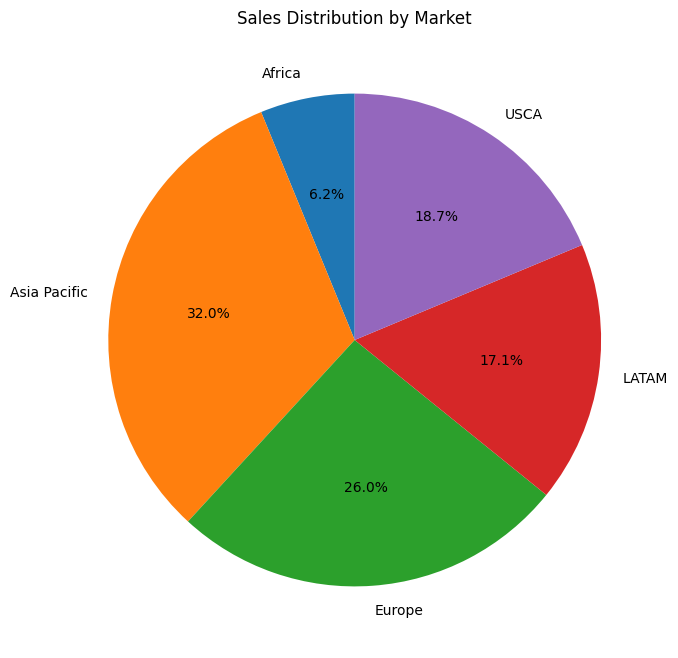

In [69]:
market_sales = orders.groupby("Market")["Sales"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    market_sales,
    labels=market_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Distribution by Market")
plt.show()

# **Shipping Analysis**

In [50]:
shipping = orders.groupby("Ship Mode").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique"),
    Average_Shipping_Days=("Shipping Days", "mean")
).reset_index()

shipping

,Ship Mode,Sales,Profit,Orders,Average_Shipping_Days
0,First Class,1.830976e+06,208104.67520,3845,2.181746
1,Same Day,6.672020e+05,76173.06780,1349,0.037394
2,Second Class,2.565672e+06,292583.52708,5146,3.230187
3,Standard Class,7.578652e+06,890596.02120,15405,4.998018


# **Shipping Days Distribution**

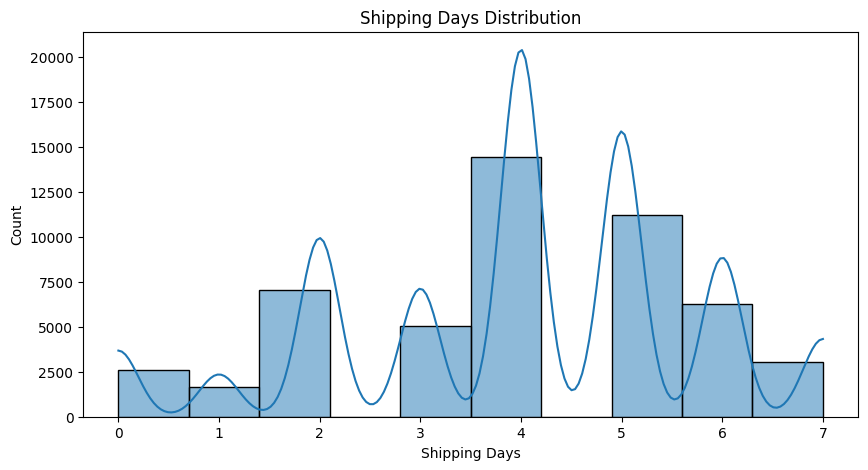

In [51]:
plt.figure(figsize=(10, 5))

sns.histplot(
    orders["Shipping Days"],
    bins=10,
    kde=True
)

plt.title("Shipping Days Distribution")
plt.xlabel("Shipping Days")

plt.show()

# **Order Distribution by Ship Mode**

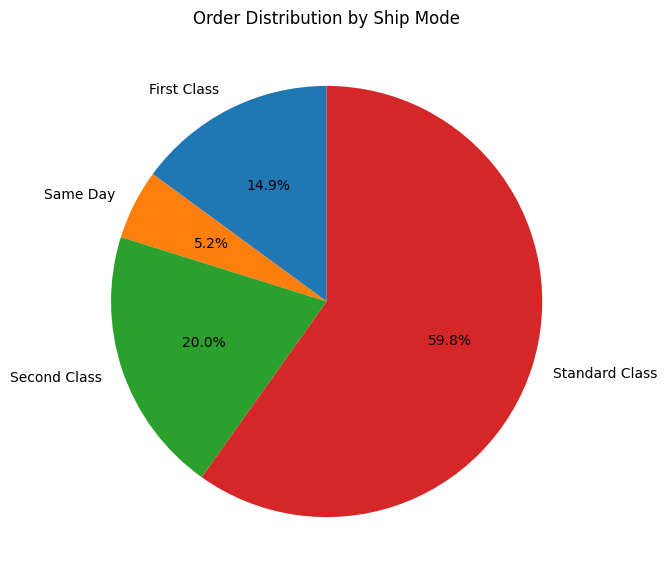

In [70]:
ship_mode_orders = orders.groupby("Ship Mode")["Order ID"].nunique()

plt.figure(figsize=(7, 7))
plt.pie(
    ship_mode_orders,
    labels=ship_mode_orders.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Order Distribution by Ship Mode")
plt.show()

# **Return Analysis**

In [53]:
returns.head()

,Returned,Order ID,Region
0,Yes,CA-2012-SA20830140-41210,Central US
1,Yes,IN-2012-PB19210127-41259,Eastern Asia
2,Yes,CA-2012-SC20095140-41174,Central US
3,Yes,IN-2015-JH158207-42140,Oceania
4,Yes,IN-2014-LC168857-41747,Oceania


In [54]:
returns.columns

Index(['Returned', 'Order ID', 'Region'], dtype='object')

In [55]:
returned_orders = returns["Order ID"].nunique()

total_orders = orders["Order ID"].nunique()

return_rate = returned_orders / total_orders * 100

print("Returned Orders:", returned_orders)
print("Total Orders:", total_orders)
print("Return Rate:", round(return_rate, 2), "%")

Returned Orders: 1079
Total Orders: 25728
Return Rate: 4.19 %


# **Profit by Category**

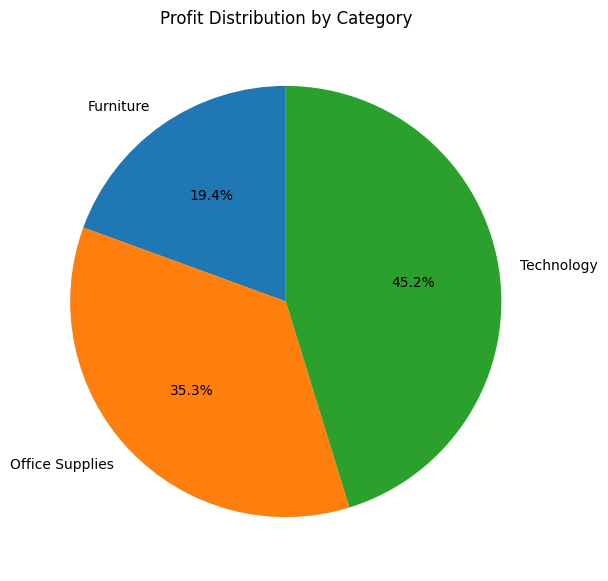

In [71]:
category_profit = orders.groupby("Category")["Profit"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    category_profit,
    labels=category_profit.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Profit Distribution by Category")
plt.show()

# **Merge Returns with Orders**

In [56]:
orders_returns = orders.merge(
    returns[["Order ID", "Returned"]],
    on="Order ID",
    how="left"
)

orders_returns["Returned"] = orders_returns["Returned"].fillna("No")

In [57]:
orders_returns["Returned"].value_counts()

,count
Returned,
No,49070
Yes,2220


# **Returns by Category**

In [58]:
return_category = orders_returns.groupby(
    "Category"
).agg(
    Orders=("Order ID", "nunique")
).reset_index()

returned_category = orders_returns[
    orders_returns["Returned"] == "Yes"
].groupby("Category")[
    "Order ID"
].nunique()

return_category["Returned Orders"] = (
    return_category["Category"]
    .map(returned_category)
    .fillna(0)
)

return_category["Return Rate %"] = (
    return_category["Returned Orders"] /
    return_category["Orders"] * 100
)

return_category

,Category,Orders,Returned Orders,Return Rate %
0,Furniture,8222,353,4.293359
1,Office Supplies,19464,806,4.140978
2,Technology,8428,365,4.330802


# **Returns by Region**

In [59]:
return_region = orders_returns.groupby(
    "Region"
).agg(
    Orders=("Order ID", "nunique")
).reset_index()

returned_region = orders_returns[
    orders_returns["Returned"] == "Yes"
].groupby("Region")[
    "Order ID"
].nunique()

return_region["Returned Orders"] = (
    return_region["Region"]
    .map(returned_region)
    .fillna(0)
)

return_region["Return Rate %"] = (
    return_region["Returned Orders"] /
    return_region["Orders"] * 100
)

return_region.sort_values(
    "Return Rate %",
    ascending=False
)

,Region,Orders,Returned Orders,Return Rate %
18,Southern US,822,44,5.352798
17,Southern Europe,1098,55,5.009107
9,Eastern US,1401,69,4.925054
15,Southern Africa,241,11,4.564315
7,Eastern Asia,1162,53,4.561102
12,Oceania,1743,78,4.475043
22,Western US,1611,72,4.469274
16,Southern Asia,1346,58,4.309064
14,Southeastern Asia,1517,64,4.218853
13,South America,1457,61,4.186685


# **Correlation Analysis**

In [60]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Cost",
    "Shipping Days"
]

correlation = orders[numeric_cols].corr()

correlation

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping Days
Sales,1.000000,0.313577,-0.086722,0.484918,0.767835,-0.004660
Quantity,0.313577,1.000000,-0.019875,0.104365,0.271804,0.004347
Discount,-0.086722,-0.019875,1.000000,-0.316490,-0.078153,-0.001507
Profit,0.484918,0.104365,-0.316490,1.000000,0.354423,0.001745
Shipping Cost,0.767835,0.271804,-0.078153,0.354423,1.000000,-0.142551
Shipping Days,-0.004660,0.004347,-0.001507,0.001745,-0.142551,1.000000


# **Heatmap:**

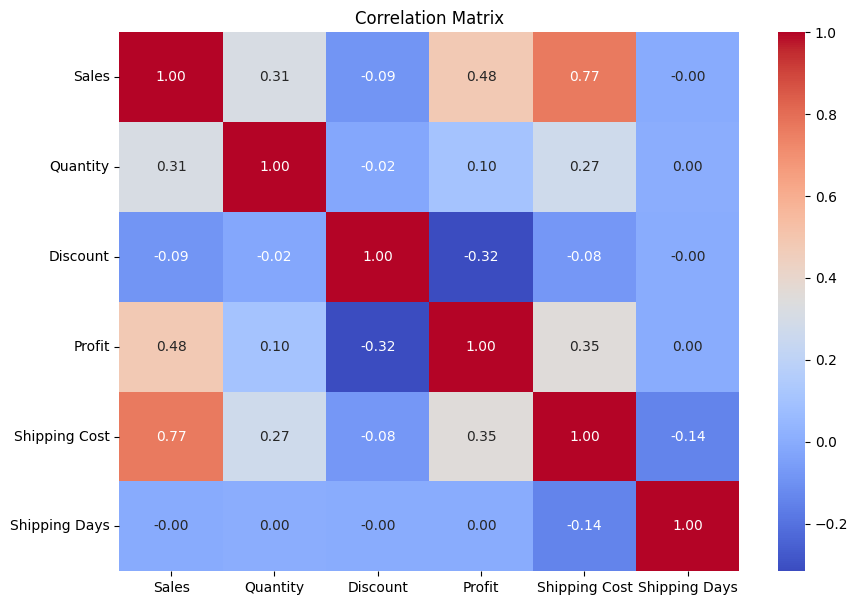

In [61]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# **Geographic Analysis**

# Top countries by sales:

In [62]:
country = orders.groupby("Country").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()

country.sort_values(
    "Sales",
    ascending=False
).head(15)

,Country,Sales,Profit
156,United States,2.297201e+06,286397.02170
6,Australia,9.252359e+05,103907.43300
50,France,8.589311e+05,109029.00300
30,China,7.005620e+05,150683.08500
54,Germany,6.281362e+05,107190.32550
94,Mexico,6.215526e+05,102453.58552
66,India,5.894860e+05,129050.59500
155,United Kingdom,5.285763e+05,111900.15000
67,Indonesia,4.048875e+05,15608.67790
20,Brazil,3.599249e+05,29686.89896


# Top countries by profit:

In [63]:
country.sort_values(
    "Profit",
    ascending=False
).head(15)

,Country,Sales,Profit
156,United States,2.297201e+06,286397.02170
30,China,7.005620e+05,150683.08500
66,India,5.894860e+05,129050.59500
155,United Kingdom,5.285763e+05,111900.15000
50,France,8.589311e+05,109029.00300
54,Germany,6.281362e+05,107190.32550
6,Australia,9.252359e+05,103907.43300
94,Mexico,6.215526e+05,102453.58552
134,Spain,2.871467e+05,54390.12000
44,El Salvador,1.775549e+05,42023.24320


# Loss-making countries:

In [64]:
country[
    country["Profit"] < 0
].sort_values("Profit").head(15)

,Country,Sales,Profit
150,Turkey,108507.94800,-98447.23200
107,Nigeria,54350.35200,-80750.71800
103,Netherlands,77514.94500,-41070.07500
63,Honduras,90125.64860,-29482.37140
110,Pakistan,58872.61200,-22446.64800
4,Argentina,57511.78328,-18693.79672
111,Panama,51539.92752,-17723.45248
139,Sweden,30491.40300,-17519.36700
115,Philippines,183420.16500,-16128.22500
132,South Korea,33125.37900,-12792.83100


# **Automated Business Summary**

In [65]:
print("========== BUSINESS SUMMARY ==========")

print(f"Total Sales: ${orders['Sales'].sum():,.2f}")
print(f"Total Profit: ${orders['Profit'].sum():,.2f}")
print(f"Profit Margin: {(orders['Profit'].sum()/orders['Sales'].sum())*100:.2f}%")
print(f"Total Orders: {orders['Order ID'].nunique():,}")
print(f"Total Customers: {orders['Customer ID'].nunique():,}")
print(f"Total Products: {orders['Product ID'].nunique():,}")

best_category = category.loc[
    category["Profit"].idxmax(), "Category"
]

worst_category = category.loc[
    category["Profit"].idxmin(), "Category"
]

best_market = market.loc[
    market["Profit"].idxmax(), "Market"
]

worst_market = market.loc[
    market["Profit"].idxmin(), "Market"
]

print(f"Most Profitable Category: {best_category}")
print(f"Least Profitable Category: {worst_category}")
print(f"Most Profitable Market: {best_market}")
print(f"Least Profitable Market: {worst_market}")

========== BUSINESS SUMMARY ==========
Total Sales: $12,642,501.91
Total Profit: $1,467,457.29
Profit Margin: 11.61%
Total Orders: 25,728
Total Customers: 17,415
Total Products: 3,788
Most Profitable Category: Technology
Least Profitable Category: Furniture
Most Profitable Market: Europe
Least Profitable Market: Africa


# **Final Analysis Table**

In [66]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Quantity",
        "Average Order Value",
        "Average Discount",
        "Average Shipping Days",
        "Return Rate"
    ],
    "Value": [
        orders["Sales"].sum(),
        orders["Profit"].sum(),
        orders["Profit"].sum() / orders["Sales"].sum() * 100,
        orders["Order ID"].nunique(),
        orders["Customer ID"].nunique(),
        orders["Product ID"].nunique(),
        orders["Quantity"].sum(),
        orders["Sales"].sum() / orders["Order ID"].nunique(),
        orders["Discount"].mean() * 100,
        orders["Shipping Days"].mean(),
        return_rate
    ]
})

summary

,Metric,Value
0,Total Sales,1.264250e+07
1,Total Profit,1.467457e+06
2,Profit Margin,1.160733e+01
3,Total Orders,2.572800e+04
4,Total Customers,1.741500e+04
5,Total Products,3.788000e+03
6,Total Quantity,1.783120e+05
7,Average Order Value,4.913908e+02
8,Average Discount,1.429075e+01
9,Average Shipping Days,3.969370e+00
